# SaaS Product Analytics & Churn Prediction

## 07 — Churn Prediction

### Objective

Build a machine-learning system that predicts which SaaS customers are likely to churn in the future.

This notebook converts the descriptive churn analysis from `06_Churn_Analysis.ipynb` into a predictive modeling problem.

### Modeling Strategy

Instead of using customer information from the entire subscription lifetime, we create:

**Observation Window**

Customer information available up to a specific cutoff date.

↓

**Prediction Window**

Whether the customer churns during the following period.

This prevents future information from leaking into the model.

### Models

- Dummy Classifier
- Logistic Regression
- Random Forest
- XGBoost

### Evaluation

Because churn datasets are often imbalanced, model evaluation will focus on:

- ROC-AUC
- PR-AUC
- Precision
- Recall
- F1 Score
- Confusion Matrix
- Business-oriented threshold analysis

### Important Principle

The objective is not simply to maximize accuracy.

A useful churn model should help the business identify customers who are likely to leave while minimizing unnecessary retention interventions.

In [1]:
from pathlib import Path

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Project Configuration

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
ANALYTICS_DIR = PROJECT_ROOT / "data" / "analytics"
MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:")
print(PROJECT_ROOT)

print("\nAnalytics directory:")
print(ANALYTICS_DIR)

print("\nModel directory:")
print(MODEL_DIR)

Project root:
c:\Users\user\Desktop\Data Analysis Projects\SaaS Product Analytics & Churn Prediction

Analytics directory:
c:\Users\user\Desktop\Data Analysis Projects\SaaS Product Analytics & Churn Prediction\data\analytics

Model directory:
c:\Users\user\Desktop\Data Analysis Projects\SaaS Product Analytics & Churn Prediction\models


## 2. Load Source Data

The prediction dataset will be constructed from:

- Users
- Events
- Subscriptions

The previously generated churn-analysis dataset may also be used for validation and comparison, but the predictive target must be constructed using time-aware logic.

In [3]:
def load_dataset(filename):

    processed_path = PROCESSED_DATA_DIR / filename
    raw_path = RAW_DATA_DIR / filename

    if processed_path.exists():
        print(f"Loading processed dataset: {filename}")
        return pd.read_csv(processed_path)

    if raw_path.exists():
        print(f"Loading raw dataset: {filename}")
        return pd.read_csv(raw_path)

    raise FileNotFoundError(
        f"Dataset not found: {filename}"
    )


users = load_dataset("users.csv")
events = load_dataset("events.csv")
subscriptions = load_dataset("subscriptions.csv")

print("\nDataset sizes:")
print(f"Users: {len(users):,}")
print(f"Events: {len(events):,}")
print(f"Subscriptions: {len(subscriptions):,}")

Loading processed dataset: users.csv
Loading processed dataset: events.csv
Loading processed dataset: subscriptions.csv

Dataset sizes:
Users: 30,000
Events: 1,552,178
Subscriptions: 30,000


## 3. Inspect Subscription Data

Before creating the prediction target, inspect:

- Subscription dates
- Status
- Plan
- Billing frequency
- Revenue
- Tenure

In [4]:
print("Subscription columns:")
print(subscriptions.columns.tolist())

print("\nStatus distribution:")

display(
    subscriptions[
        "status"
    ]
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="subscriptions")
)

Subscription columns:
['subscription_id', 'user_id', 'company_id', 'plan', 'subscription_start_date', 'subscription_end_date', 'billing_frequency', 'monthly_recurring_revenue', 'annual_contract_value', 'trial', 'status', 'acquisition_source', 'upgrade_count', 'downgrade_count', 'tenure_days']

Status distribution:


,status,subscriptions
0,Active,15159
1,Free,11993
2,Churned,2848


## 4. Standardize Dates

In [5]:
for column in [
    "subscription_start_date",
    "subscription_end_date",
]:

    if column in subscriptions.columns:

        subscriptions[column] = pd.to_datetime(
            subscriptions[column],
            errors="coerce",
        )


event_date_column = None

for column in [
    "event_date",
    "date",
    "timestamp",
    "event_timestamp",
    "created_at",
]:

    if column in events.columns:
        event_date_column = column
        break


if event_date_column is None:

    raise ValueError(
        "Could not identify event date column."
    )


events[event_date_column] = pd.to_datetime(
    events[event_date_column],
    errors="coerce",
)

print(
    "Event date range:",
    events[event_date_column].min(),
    "to",
    events[event_date_column].max(),
)

Event date range: 2024-01-05 13:54:32 to 2026-07-31 23:59:53


## 5. Determine Analysis Date

The final event date represents the latest point for which product activity is available.

We use this date to construct historical observation and future prediction windows.

In [6]:
analysis_end_date = (
    events[event_date_column]
    .dropna()
    .max()
)

print(
    "Analysis end date:",
    analysis_end_date
)

Analysis end date: 2026-07-31 23:59:53


## 6. Define Prediction Framework

We will use:

### Observation Window

The previous **90 days**.

Customer behavior during this period becomes the model's input.

### Prediction Window

The following **30 days**.

If the customer churns during this period:

`target = 1`

Otherwise:

`target = 0`

### Example

If:

`cutoff_date = 2026-05-01`

Then:

```text
Observation:
2026-02-01 → 2026-05-01

Prediction:
2026-05-01 → 2026-05-31

In [7]:
OBSERVATION_DAYS = 90
PREDICTION_DAYS = 30

print(
    f"Observation window: "
    f"{OBSERVATION_DAYS} days"
)

print(
    f"Prediction window: "
    f"{PREDICTION_DAYS} days"
)

Observation window: 90 days
Prediction window: 30 days


## 7. Select Historical Cutoff Dates

A single cutoff date can produce a relatively small training dataset.

Instead, we create multiple historical snapshots.

Each snapshot asks:

> Given what we knew about the customer at this date, did they churn during the following 30 days?

This creates a more realistic training dataset.

In [8]:
event_min_date = (
    events[event_date_column]
    .dropna()
    .min()
)

event_max_date = (
    events[event_date_column]
    .dropna()
    .max()
)

first_possible_cutoff = (
    event_min_date
    + pd.Timedelta(
        days=OBSERVATION_DAYS
    )
)

last_possible_cutoff = (
    event_max_date
    - pd.Timedelta(
        days=PREDICTION_DAYS
    )
)

cutoff_dates = pd.date_range(
    start=first_possible_cutoff,
    end=last_possible_cutoff,
    freq="MS",
)

print(
    "First cutoff:",
    first_possible_cutoff
)

print(
    "Last cutoff:",
    last_possible_cutoff
)

print(
    "Number of cutoff snapshots:",
    len(cutoff_dates)
)

First cutoff: 2024-04-04 13:54:32
Last cutoff: 2026-07-01 23:59:53
Number of cutoff snapshots: 27


## 8. Create Event-Level Historical Features

For every customer and cutoff date we calculate only information available during the observation window.

Features:

- Total events
- Active days
- Active months
- Average events per active day
- First activity
- Last activity
- Recency

In [9]:
events_model = events[
    [
        "user_id",
        event_date_column,
    ]
].copy()

events_model = events_model.dropna(
    subset=[
        "user_id",
        event_date_column,
    ]
)

events_model["event_day"] = (
    events_model[event_date_column]
    .dt.normalize()
)

events_model["event_month"] = (
    events_model["event_day"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

print(
    f"Clean event records: "
    f"{len(events_model):,}"
)

Clean event records: 1,552,178


## 9. Create Customer Snapshot Dataset

For each cutoff date:

1. Select events from the previous 90 days.
2. Aggregate customer activity.
3. Determine whether the customer is eligible for prediction.
4. Determine whether the customer churned during the following 30 days.

In [10]:
def create_snapshot(
    cutoff_date,
    events_df,
    subscriptions_df,
):
    
    observation_start = (
        cutoff_date
        - pd.Timedelta(
            days=OBSERVATION_DAYS
        )
    )

    prediction_end = (
        cutoff_date
        + pd.Timedelta(
            days=PREDICTION_DAYS
        )
    )

    observation_events = events_df[
        (
            events_df["event_day"]
            > observation_start
        )
        &
        (
            events_df["event_day"]
            <= cutoff_date
        )
    ].copy()

    if len(observation_events) == 0:
        return pd.DataFrame()

    activity = (
        observation_events
        .groupby("user_id")
        .agg(
            total_events=(
                "user_id",
                "size",
            ),
            active_days=(
                "event_day",
                "nunique",
            ),
            active_months=(
                "event_month",
                "nunique",
            ),
            first_activity=(
                "event_day",
                "min",
            ),
            last_activity=(
                "event_day",
                "max",
            ),
        )
        .reset_index()
    )

    activity["activity_recency_days"] = (
        cutoff_date
        - activity["last_activity"]
    ).dt.days

    activity["avg_events_per_active_day"] = (
        activity["total_events"]
        /
        activity["active_days"].replace(
            0,
            np.nan
        )
    )

    snapshot = activity.copy()

    snapshot["cutoff_date"] = cutoff_date

    # Identify whether the customer had a subscription
    # active at the observation cutoff.
    active_subscriptions = subscriptions_df[
        (
            subscriptions_df[
                "subscription_start_date"
            ]
            <= cutoff_date
        )
        &
        (
            subscriptions_df[
                "subscription_end_date"
            ].isna()
            |
            (
                subscriptions_df[
                    "subscription_end_date"
                ]
                > cutoff_date
            )
        )
    ].copy()

    subscription_features = (
        active_subscriptions
        .sort_values(
            "subscription_start_date"
        )
        .drop_duplicates(
            "user_id",
            keep="last"
        )
    )

    subscription_features[
        "tenure_days_at_cutoff"
    ] = (
        cutoff_date
        -
        subscription_features[
            "subscription_start_date"
        ]
    ).dt.days

    subscription_features[
        "tenure_months_at_cutoff"
    ] = (
        subscription_features[
            "tenure_days_at_cutoff"
        ]
        / 30.44
    )

    subscription_features[
        "churn_in_prediction_window"
    ] = (
        (
            subscription_features[
                "subscription_end_date"
            ]
            > cutoff_date
        )
        &
        (
            subscription_features[
                "subscription_end_date"
            ]
            <= prediction_end
        )
    ).astype(int)

    subscription_features = (
        subscription_features[
            [
                "user_id",
                "plan",
                "billing_frequency",
                "monthly_recurring_revenue",
                "trial",
                "acquisition_source",
                "tenure_days_at_cutoff",
                "tenure_months_at_cutoff",
                "churn_in_prediction_window",
            ]
        ]
    )

    snapshot = snapshot.merge(
        subscription_features,
        on="user_id",
        how="inner",
    )

    return snapshot

## 10. Generate Historical Snapshots

We now build the full modeling dataset.

Each row represents:

> One customer at one historical cutoff date.

In [11]:
snapshots = []

for i, cutoff_date in enumerate(
    cutoff_dates,
    start=1
):

    snapshot = create_snapshot(
        cutoff_date,
        events_model,
        subscriptions,
    )

    if len(snapshot) > 0:
        snapshots.append(snapshot)

    if i % 5 == 0:
        print(
            f"Processed "
            f"{i}/{len(cutoff_dates)} "
            f"cutoff dates"
        )


prediction_data = pd.concat(
    snapshots,
    ignore_index=True,
)

print(
    "\nPrediction dataset shape:",
    prediction_data.shape
)

Processed 5/27 cutoff dates
Processed 10/27 cutoff dates
Processed 15/27 cutoff dates
Processed 20/27 cutoff dates
Processed 25/27 cutoff dates

Prediction dataset shape: (409637, 17)


## 11. Inspect the Prediction Dataset

In [12]:
display(
    prediction_data.head()
)

print(
    "\nColumns:"
)

print(
    prediction_data.columns.tolist()
)

,user_id,total_events,active_days,active_months,first_activity,last_activity,activity_recency_days,avg_events_per_active_day,cutoff_date,plan,billing_frequency,monthly_recurring_revenue,trial,acquisition_source,tenure_days_at_cutoff,tenure_months_at_cutoff,churn_in_prediction_window
0,U000002,3,3,2,2024-03-10,2024-04-12,19,1.0000,2024-05-01 13:54:32,Free,NaN,0.0000,True,Self-Serve,73,2.3982,0
1,U000006,6,6,2,2024-02-03,2024-04-27,4,1.0000,2024-05-01 13:54:32,Starter,Monthly,29.0000,True,Sales-Assisted,106,3.4823,0
2,U000011,4,4,2,2024-03-23,2024-04-15,16,1.0000,2024-05-01 13:54:32,Enterprise,Monthly,199.0000,True,Partner,41,1.3469,0
3,U000014,2,2,2,2024-03-20,2024-04-12,19,1.0000,2024-05-01 13:54:32,Free,NaN,0.0000,True,Self-Serve,77,2.5296,0
4,U000027,1,1,1,2024-04-21,2024-04-21,10,1.0000,2024-05-01 13:54:32,Professional,Monthly,79.0000,True,Partner,11,0.3614,0



Columns:
['user_id', 'total_events', 'active_days', 'active_months', 'first_activity', 'last_activity', 'activity_recency_days', 'avg_events_per_active_day', 'cutoff_date', 'plan', 'billing_frequency', 'monthly_recurring_revenue', 'trial', 'acquisition_source', 'tenure_days_at_cutoff', 'tenure_months_at_cutoff', 'churn_in_prediction_window']


## 12. Check Target Distribution

The target variable is:

`churn_in_prediction_window`

- `1` → customer churned during the following 30 days
- `0` → customer did not churn during the following 30 days

We need to inspect class balance before modeling.

In [13]:
target_column = (
    "churn_in_prediction_window"
)

target_distribution = (
    prediction_data[
        target_column
    ]
    .value_counts()
    .sort_index()
)

display(
    target_distribution
)

print(
    "\nChurn rate:"
)

print(
    prediction_data[
        target_column
    ].mean()
    * 100
)

churn_in_prediction_window
0    406869
1      2768
Name: count, dtype: int64


Churn rate:
0.6757202108207998


## 13. Remove Invalid Rows

Rows without a valid target cannot be used for supervised learning.

We also remove duplicate customer/cutoff combinations.

In [14]:
prediction_data = (
    prediction_data
    .dropna(
        subset=[
            target_column
        ]
    )
    .copy()
)

prediction_data = (
    prediction_data
    .drop_duplicates(
        subset=[
            "user_id",
            "cutoff_date",
        ]
    )
)

print(
    "Final prediction dataset:",
    prediction_data.shape
)

Final prediction dataset: (409637, 17)


## 14. Feature Engineering

We now create additional behavioral features.

### Engagement

- Events per active day
- Events per active month

### Recency

- Activity recency

### Lifecycle

- Tenure months

### Commercial

- Monthly recurring revenue

These features are all calculated using information available at the cutoff date.

In [15]:
prediction_data[
    "events_per_active_month"
] = (
    prediction_data[
        "total_events"
    ]
    /
    prediction_data[
        "active_months"
    ].replace(
        0,
        np.nan
    )
)

prediction_data[
    "events_per_tenure_month"
] = (
    prediction_data[
        "total_events"
    ]
    /
    prediction_data[
        "tenure_months_at_cutoff"
    ].replace(
        0,
        np.nan
    )
)

prediction_data[
    "is_recently_active"
] = (
    prediction_data[
        "activity_recency_days"
    ]
    <= 14
).astype(int)

prediction_data[
    "is_low_engagement"
] = (
    prediction_data[
        "total_events"
    ]
    <= 5
).astype(int)

display(
    prediction_data.head()
)

,user_id,total_events,active_days,active_months,first_activity,last_activity,activity_recency_days,avg_events_per_active_day,cutoff_date,plan,billing_frequency,monthly_recurring_revenue,trial,acquisition_source,tenure_days_at_cutoff,tenure_months_at_cutoff,churn_in_prediction_window,events_per_active_month,events_per_tenure_month,is_recently_active,is_low_engagement
0,U000002,3,3,2,2024-03-10,2024-04-12,19,1.0000,2024-05-01 13:54:32,Free,NaN,0.0000,True,Self-Serve,73,2.3982,0,1.5000,1.2510,0,1
1,U000006,6,6,2,2024-02-03,2024-04-27,4,1.0000,2024-05-01 13:54:32,Starter,Monthly,29.0000,True,Sales-Assisted,106,3.4823,0,3.0000,1.7230,1,0
2,U000011,4,4,2,2024-03-23,2024-04-15,16,1.0000,2024-05-01 13:54:32,Enterprise,Monthly,199.0000,True,Partner,41,1.3469,0,2.0000,2.9698,0,1
3,U000014,2,2,2,2024-03-20,2024-04-12,19,1.0000,2024-05-01 13:54:32,Free,NaN,0.0000,True,Self-Serve,77,2.5296,0,1.0000,0.7906,0,1
4,U000027,1,1,1,2024-04-21,2024-04-21,10,1.0000,2024-05-01 13:54:32,Professional,Monthly,79.0000,True,Partner,11,0.3614,0,1.0000,2.7673,1,1


## 15. Select Modeling Features

We intentionally exclude:

- User ID
- Subscription ID
- Future dates
- Target
- Any information created after the cutoff

The model should learn generalizable customer behavior rather than memorize individual customers.

In [16]:
feature_columns = [
    "total_events",
    "active_days",
    "active_months",
    "activity_recency_days",
    "avg_events_per_active_day",
    "events_per_active_month",
    "events_per_tenure_month",
    "tenure_days_at_cutoff",
    "tenure_months_at_cutoff",
    "monthly_recurring_revenue",
    "trial",
    "is_recently_active",
    "is_low_engagement",
    "plan",
    "billing_frequency",
    "acquisition_source",
]

feature_columns = [
    column
    for column in feature_columns
    if column in prediction_data.columns
]

print(
    "Model features:"
)

for feature in feature_columns:
    print(
        f"- {feature}"
    )

Model features:
- total_events
- active_days
- active_months
- activity_recency_days
- avg_events_per_active_day
- events_per_active_month
- events_per_tenure_month
- tenure_days_at_cutoff
- tenure_months_at_cutoff
- monthly_recurring_revenue
- trial
- is_recently_active
- is_low_engagement
- plan
- billing_frequency
- acquisition_source


## 16. Define X and y

In [17]:
X = prediction_data[
    feature_columns
].copy()

y = prediction_data[
    target_column
].astype(int)

print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

print(
    "\nTarget distribution:"
)

print(
    y.value_counts(
        normalize=True
    )
)

X shape: (409637, 16)
y shape: (409637,)

Target distribution:
churn_in_prediction_window
0   0.9932
1   0.0068
Name: proportion, dtype: float64


## 17. Time-Based Train/Test Split

Random splitting is not ideal for this problem because historical observations should be used to predict future observations.

Therefore:

### Training

Earlier cutoff dates.

### Testing

Later cutoff dates.

This better represents how the model would operate in production.

In [18]:
prediction_data = (
    prediction_data
    .sort_values(
        "cutoff_date"
    )
    .reset_index(
        drop=True
    )
)

unique_cutoffs = (
    prediction_data[
        "cutoff_date"
    ]
    .sort_values()
    .unique()
)

split_index = int(
    len(unique_cutoffs) * 0.80
)

train_cutoffs = unique_cutoffs[
    :split_index
]

test_cutoffs = unique_cutoffs[
    split_index:
]

train_mask = (
    prediction_data[
        "cutoff_date"
    ]
    .isin(train_cutoffs)
)

test_mask = (
    prediction_data[
        "cutoff_date"
    ]
    .isin(test_cutoffs)
)

X_train = prediction_data.loc[
    train_mask,
    feature_columns,
]

X_test = prediction_data.loc[
    test_mask,
    feature_columns,
]

y_train = prediction_data.loc[
    train_mask,
    target_column,
]

y_test = prediction_data.loc[
    test_mask,
    target_column,
]

print(
    "Training period:",
    train_cutoffs.min(),
    "to",
    train_cutoffs.max()
)

print(
    "Testing period:",
    test_cutoffs.min(),
    "to",
    test_cutoffs.max()
)

print(
    "\nTraining rows:",
    len(X_train)
)

print(
    "Testing rows:",
    len(X_test)
)

Training period: 2024-05-01 13:54:32 to 2026-01-01 13:54:32
Testing period: 2026-02-01 13:54:32 to 2026-07-01 13:54:32

Training rows: 262943
Testing rows: 146694


## 18. Identify Numerical and Categorical Features

In [19]:
numeric_features = X_train.select_dtypes(
    include=[
        "number"
    ]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=[
        "object",
        "category",
        "bool",
    ]
).columns.tolist()

print(
    "Numerical features:"
)

print(
    numeric_features
)

print(
    "\nCategorical features:"
)

print(
    categorical_features
)

Numerical features:
['total_events', 'active_days', 'active_months', 'activity_recency_days', 'avg_events_per_active_day', 'events_per_active_month', 'events_per_tenure_month', 'tenure_days_at_cutoff', 'tenure_months_at_cutoff', 'monthly_recurring_revenue', 'is_recently_active', 'is_low_engagement']

Categorical features:
['trial', 'plan', 'billing_frequency', 'acquisition_source']


## 19. Build Preprocessing Pipeline

Numerical features:

- Median imputation
- Standardization

Categorical features:

- Most-frequent imputation
- One-hot encoding

Using a pipeline prevents preprocessing leakage between training and testing data.

In [20]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ]
)

## 20. Baseline Model

The baseline predicts the majority class.

This establishes the minimum performance that a useful model should exceed.

In [21]:
baseline_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "model",
            DummyClassifier(
                strategy="most_frequent"
            ),
        ),
    ]
)

baseline_model.fit(
    X_train,
    y_train,
)

baseline_predictions = (
    baseline_model.predict(
        X_test
    )
)

baseline_probability = (
    baseline_model.predict_proba(
        X_test
    )[:, 1]
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions,
    zero_division=0,
)

baseline_auc = roc_auc_score(
    y_test,
    baseline_probability,
)

print(
    f"Baseline F1: "
    f"{baseline_f1:.4f}"
)

print(
    f"Baseline ROC-AUC: "
    f"{baseline_auc:.4f}"
)

Baseline F1: 0.0000
Baseline ROC-AUC: 0.5000


## 21. Logistic Regression

Logistic Regression provides an interpretable linear baseline.

It is especially useful because:

- Coefficients can be interpreted
- It is computationally efficient
- It provides probability estimates
- It establishes a strong baseline for structured business data

In [22]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

logistic_model.fit(
    X_train,
    y_train,
)

logistic_predictions = (
    logistic_model.predict(
        X_test
    )
)

logistic_probability = (
    logistic_model.predict_proba(
        X_test
    )[:, 1]
)

print(
    classification_report(
        y_test,
        logistic_predictions,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

           0       1.00      0.78      0.88    145578
           1       0.02      0.69      0.05      1116

    accuracy                           0.78    146694
   macro avg       0.51      0.73      0.46    146694
weighted avg       0.99      0.78      0.87    146694



## 22. Random Forest

Random Forest can capture:

- Non-linear relationships
- Feature interactions
- Different customer behavior patterns

It is also useful for understanding feature importance.

In [23]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

random_forest_model.fit(
    X_train,
    y_train,
)

rf_predictions = (
    random_forest_model.predict(
        X_test
    )
)

rf_probability = (
    random_forest_model.predict_proba(
        X_test
    )[:, 1]
)

## 23. XGBoost

XGBoost is evaluated as the main high-performance tree-based model.

It is particularly effective for structured tabular datasets.

In [24]:
try:

    from xgboost import XGBClassifier

    xgb_available = True

    print(
        "XGBoost available."
    )

except ImportError:

    xgb_available = False

    print(
        "XGBoost is not installed."
    )

XGBoost available.


In [25]:
if xgb_available:

    xgb_model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor,
            ),
            (
                "model",
                XGBClassifier(
                    n_estimators=300,
                    max_depth=6,
                    learning_rate=0.05,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    xgb_model.fit(
        X_train,
        y_train,
    )

    xgb_predictions = (
        xgb_model.predict(
            X_test
        )
    )

    xgb_probability = (
        xgb_model.predict_proba(
            X_test
        )[:, 1]
    )

else:

    xgb_model = None
    xgb_predictions = None
    xgb_probability = None

## 24. Model Evaluation Function

In [26]:
def evaluate_model(
    model_name,
    y_true,
    predictions,
    probabilities,
):

    return {
        "model": model_name,
        "accuracy": accuracy_score(
            y_true,
            predictions,
        ),
        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            y_true,
            probabilities,
        ),
        "pr_auc": average_precision_score(
            y_true,
            probabilities,
        ),
    }

In [27]:
results = []

results.append(
    evaluate_model(
        "Baseline",
        y_test,
        baseline_predictions,
        baseline_probability,
    )
)

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_predictions,
        logistic_probability,
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions,
        rf_probability,
    )
)

if xgb_available:

    results.append(
        evaluate_model(
            "XGBoost",
            y_test,
            xgb_predictions,
            xgb_probability,
        )
    )

model_results = pd.DataFrame(
    results
).sort_values(
    "pr_auc",
    ascending=False,
)

display(
    model_results
)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
1,Logistic Regression,0.7798,0.0235,0.6891,0.0455,0.8161,0.0279
2,Random Forest,0.8812,0.0244,0.3746,0.0458,0.7944,0.0228
3,XGBoost,0.9924,0.0000,0.0000,0.0000,0.8196,0.0223
0,Baseline,0.9924,0.0000,0.0000,0.0000,0.5000,0.0076


## 25. Why PR-AUC Matters

Churn prediction is often an imbalanced classification problem.

ROC-AUC can remain relatively strong even when the model performs poorly at identifying the minority churn class.

Therefore, PR-AUC is particularly useful because it evaluates the relationship between:

- Precision
- Recall

for the positive churn class.

In [28]:
best_model_name = (
    model_results.iloc[0]["model"]
)

print(
    "Best model by PR-AUC:",
    best_model_name
)

Best model by PR-AUC: Logistic Regression


In [29]:
model_objects = {
    "Baseline": baseline_model,
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
}

probability_objects = {
    "Baseline": baseline_probability,
    "Logistic Regression": logistic_probability,
    "Random Forest": rf_probability,
}

prediction_objects = {
    "Baseline": baseline_predictions,
    "Logistic Regression": logistic_predictions,
    "Random Forest": rf_predictions,
}

if xgb_available:

    model_objects[
        "XGBoost"
    ] = xgb_model

    probability_objects[
        "XGBoost"
    ] = xgb_probability

    prediction_objects[
        "XGBoost"
    ] = xgb_predictions


best_model = model_objects[
    best_model_name
]

best_probability = probability_objects[
    best_model_name
]

best_predictions = prediction_objects[
    best_model_name
]

cm = confusion_matrix(
    y_test,
    best_predictions,
)

print(
    cm
)

[[113626  31952]
 [   347    769]]


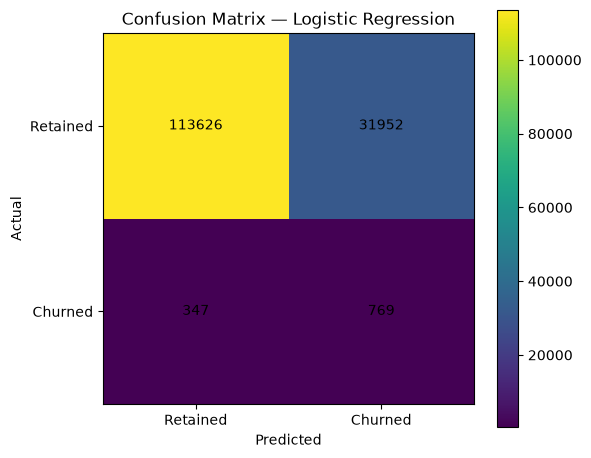

In [30]:
plt.figure(
    figsize=(6, 5)
)

plt.imshow(
    cm
)

plt.title(
    f"Confusion Matrix — {best_model_name}"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.xticks(
    [0, 1],
    ["Retained", "Churned"]
)

plt.yticks(
    [0, 1],
    ["Retained", "Churned"]
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
        )

plt.colorbar()

plt.tight_layout()

plt.show()

## 27. ROC Curve

Compare the ability of the models to distinguish churned customers from retained customers.

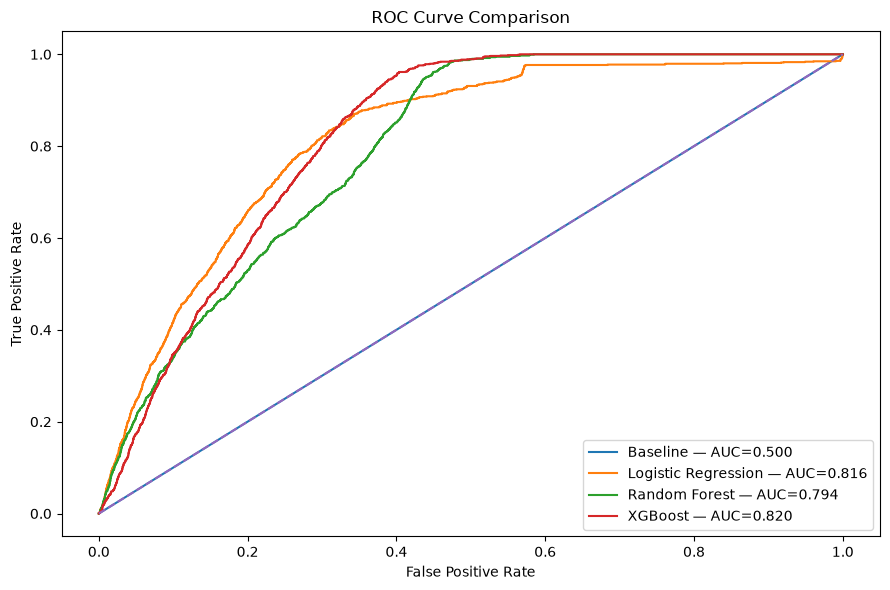

In [31]:
plt.figure(
    figsize=(9, 6)
)

for model_name, probabilities in probability_objects.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities,
    )

    auc = roc_auc_score(
        y_test,
        probabilities,
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} — AUC={auc:.3f}",
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
)

plt.title(
    "ROC Curve Comparison"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend()

plt.tight_layout()

plt.show()

## 28. Precision-Recall Curve

Because churn may be relatively rare, the Precision-Recall curve is especially important.

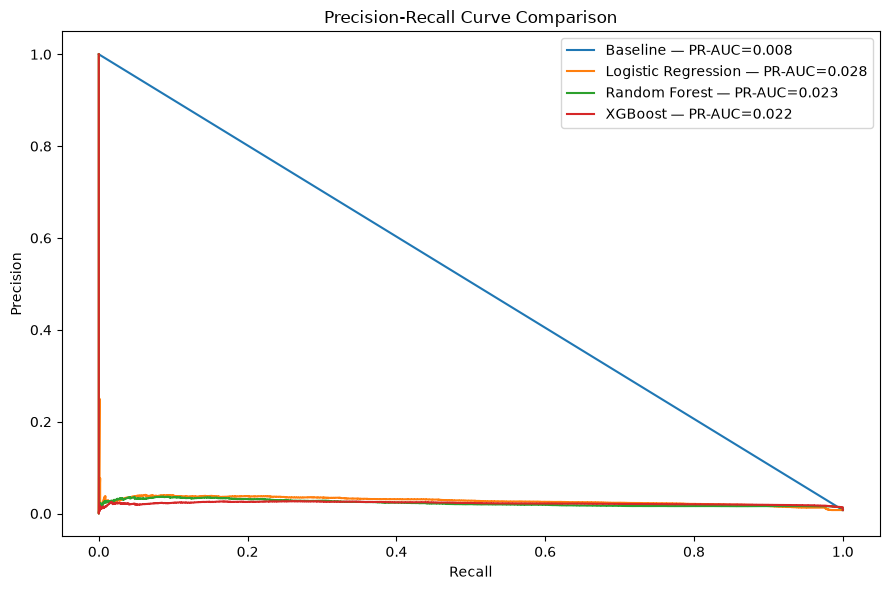

In [32]:
plt.figure(
    figsize=(9, 6)
)

for model_name, probabilities in probability_objects.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities,
    )

    ap = average_precision_score(
        y_test,
        probabilities,
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} — PR-AUC={ap:.3f}",
    )

plt.title(
    "Precision-Recall Curve Comparison"
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.legend()

plt.tight_layout()

plt.show()

## 29. Threshold Analysis

A default classification threshold of `0.50` is not necessarily optimal.

For a retention team, it may be better to identify more potentially at-risk customers even if this increases false positives.

We therefore evaluate several thresholds.

In [33]:
thresholds = np.arange(
    0.10,
    0.91,
    0.05,
)

threshold_results = []

for threshold in thresholds:

    predictions = (
        best_probability
        >= threshold
    ).astype(int)

    threshold_results.append(
        {
            "threshold": threshold,
            "precision": precision_score(
                y_test,
                predictions,
                zero_division=0,
            ),
            "recall": recall_score(
                y_test,
                predictions,
                zero_division=0,
            ),
            "f1": f1_score(
                y_test,
                predictions,
                zero_division=0,
            ),
            "customers_flagged": predictions.sum(),
        }
    )

threshold_results = pd.DataFrame(
    threshold_results
)

display(
    threshold_results
)

,threshold,precision,recall,f1,customers_flagged
0,0.1000,0.0142,0.9274,0.0280,72858
1,0.1500,0.0155,0.9086,0.0305,65280
2,0.2000,0.0168,0.8961,0.0330,59413
3,0.2500,0.0181,0.8817,0.0355,54267
4,0.3000,0.0192,0.8575,0.0376,49780
5,0.3500,0.0203,0.8289,0.0396,45614
6,0.4000,0.0212,0.7885,0.0413,41534
7,0.4500,0.0224,0.7482,0.0435,37268
8,0.5000,0.0235,0.6891,0.0455,32721
9,0.5500,0.0252,0.6219,0.0484,27570


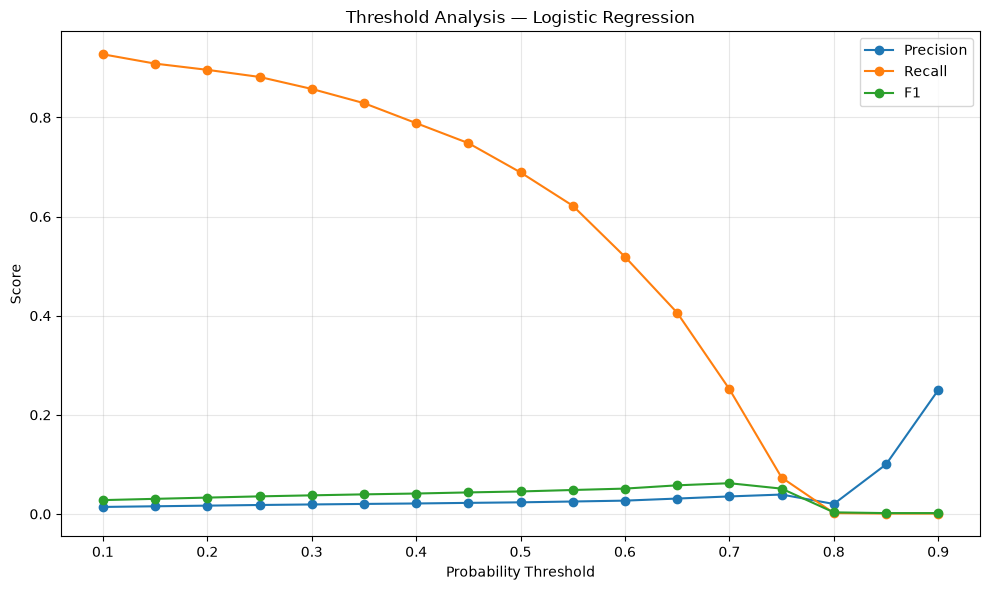

In [34]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    threshold_results[
        "threshold"
    ],
    threshold_results[
        "precision"
    ],
    marker="o",
    label="Precision",
)

plt.plot(
    threshold_results[
        "threshold"
    ],
    threshold_results[
        "recall"
    ],
    marker="o",
    label="Recall",
)

plt.plot(
    threshold_results[
        "threshold"
    ],
    threshold_results[
        "f1"
    ],
    marker="o",
    label="F1",
)

plt.title(
    f"Threshold Analysis — {best_model_name}"
)

plt.xlabel(
    "Probability Threshold"
)

plt.ylabel(
    "Score"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

## 30. Select Operational Threshold

The best threshold should not automatically be the threshold with the highest mathematical F1 score.

The business may choose a threshold based on:

- Retention-team capacity
- Cost of contacting customers
- Cost of missing a churn-risk customer
- Customer lifetime value
- Desired recall

For this project, we identify the threshold with the highest F1 as a neutral analytical reference.

In [35]:
best_threshold_row = (
    threshold_results
    .sort_values(
        "f1",
        ascending=False,
    )
    .iloc[0]
)

best_threshold = (
    best_threshold_row[
        "threshold"
    ]
)

print(
    f"Reference threshold: "
    f"{best_threshold:.2f}"
)

print(
    f"Precision: "
    f"{best_threshold_row['precision']:.4f}"
)

print(
    f"Recall: "
    f"{best_threshold_row['recall']:.4f}"
)

print(
    f"F1: "
    f"{best_threshold_row['f1']:.4f}"
)

Reference threshold: 0.70
Precision: 0.0354
Recall: 0.2518
F1: 0.0621


## 31. Generate Churn Risk Scores

We now score customers in the test period.

Each customer receives:

- Churn probability
- Risk segment
- Predicted churn flag

In [36]:
test_customers = prediction_data.loc[
    test_mask,
    [
        "user_id",
        "cutoff_date",
        "plan",
        "billing_frequency",
        "monthly_recurring_revenue",
    ],
].copy()

test_customers[
    "churn_probability"
] = best_probability

test_customers[
    "predicted_churn"
] = (
    test_customers[
        "churn_probability"
    ]
    >= best_threshold
).astype(int)

test_customers[
    "risk_segment"
] = pd.cut(
    test_customers[
        "churn_probability"
    ],
    bins=[
        -np.inf,
        0.25,
        0.50,
        0.75,
        np.inf,
    ],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High",
    ],
)

display(
    test_customers
    .sort_values(
        "churn_probability",
        ascending=False,
    )
    .head(20)
)

,user_id,cutoff_date,plan,billing_frequency,monthly_recurring_revenue,churn_probability,predicted_churn,risk_segment
397609,U003816,2026-07-01 13:54:32,Starter,Monthly,29.0000,0.9389,1,Very High
384733,U019512,2026-07-01 13:54:32,Starter,Monthly,29.0000,0.9357,1,Very High
377558,U013095,2026-06-01 13:54:32,Starter,Monthly,29.0000,0.9277,1,Very High
393641,U023625,2026-07-01 13:54:32,Professional,Monthly,79.0000,0.9081,1,Very High
370969,U004760,2026-06-01 13:54:32,Starter,Monthly,29.0000,0.8658,1,Very High
406885,U009370,2026-07-01 13:54:32,Professional,Monthly,79.0000,0.8642,1,Very High
340293,U026332,2026-05-01 13:54:32,Professional,Monthly,79.0000,0.8601,1,Very High
406570,U008548,2026-07-01 13:54:32,Professional,Annual,79.0000,0.8576,1,Very High
350325,U003202,2026-05-01 13:54:32,Enterprise,Monthly,199.0000,0.8530,1,Very High
343829,U022997,2026-05-01 13:54:32,Starter,Monthly,29.0000,0.8516,1,Very High


## 32. Risk Segment Distribution

In [37]:
risk_distribution = (
    test_customers[
        "risk_segment"
    ]
    .value_counts()
    .sort_index()
    .reset_index()
)

risk_distribution.columns = [
    "risk_segment",
    "customers",
]

display(
    risk_distribution
)

,risk_segment,customers
0,Low,92427
1,Medium,21546
2,High,30629
3,Very High,2092


## 33. High-Risk Customer Revenue

A high-risk customer with significant recurring revenue may deserve more attention than a low-value customer with the same churn probability.

We therefore combine:

**Churn Risk × Revenue**

to create a business-prioritization view.

In [38]:
test_customers[
    "risk_revenue_score"
] = (
    test_customers[
        "churn_probability"
    ]
    *
    test_customers[
        "monthly_recurring_revenue"
    ].fillna(0)
)

priority_customers = (
    test_customers
    .sort_values(
        "risk_revenue_score",
        ascending=False,
    )
)

display(
    priority_customers.head(20)
)

,user_id,cutoff_date,plan,billing_frequency,monthly_recurring_revenue,churn_probability,predicted_churn,risk_segment,risk_revenue_score
350325,U003202,2026-05-01 13:54:32,Enterprise,Monthly,199.0000,0.8530,1,Very High,169.7462
357570,U010195,2026-05-01 13:54:32,Enterprise,Monthly,199.0000,0.7850,1,Very High,156.2110
338179,U018615,2026-05-01 13:54:32,Enterprise,Monthly,199.0000,0.7751,1,Very High,154.2511
276132,U007504,2026-02-01 13:54:32,Enterprise,Annual,199.0000,0.7586,1,Very High,150.9672
369898,U024697,2026-06-01 13:54:32,Enterprise,Annual,199.0000,0.7289,1,High,145.0488
384762,U019652,2026-07-01 13:54:32,Enterprise,Monthly,199.0000,0.7202,1,High,143.3164
325559,U001880,2026-04-01 13:54:32,Enterprise,Annual,199.0000,0.7139,1,High,142.0700
317397,U028564,2026-04-01 13:54:32,Enterprise,Monthly,199.0000,0.7046,1,High,140.2118
353653,U014265,2026-05-01 13:54:32,Enterprise,Monthly,199.0000,0.7020,1,High,139.6912
270205,U029131,2026-02-01 13:54:32,Enterprise,Monthly,199.0000,0.6972,0,High,138.7490


## 34. Feature Importance

For tree-based models, feature importance helps identify which variables contributed most to predictions.

If XGBoost or Random Forest is selected as the final model, we inspect its transformed feature space.

In [39]:
tree_model_name = None

if best_model_name in [
    "Random Forest",
    "XGBoost",
]:

    tree_model_name = (
        best_model_name
    )

    fitted_preprocessor = (
        best_model.named_steps[
            "preprocessor"
        ]
    )

    tree_model = (
        best_model.named_steps[
            "model"
        ]
    )

    feature_names = (
        fitted_preprocessor
        .get_feature_names_out()
    )

    importance_values = (
        tree_model
        .feature_importances_
    )

    feature_importance = (
        pd.DataFrame(
            {
                "feature": feature_names,
                "importance": importance_values,
            }
        )
        .sort_values(
            "importance",
            ascending=False,
        )
    )

    display(
        feature_importance.head(20)
    )

else:

    feature_importance = None

    print(
        "Best model is not a tree-based model."
    )

Best model is not a tree-based model.


In [40]:
if feature_importance is not None:

    top_features = (
        feature_importance
        .head(15)
        .sort_values(
            "importance"
        )
    )

    plt.figure(
        figsize=(10, 7)
    )

    plt.barh(
        top_features[
            "feature"
        ],
        top_features[
            "importance"
        ],
    )

    plt.title(
        f"Top Churn Prediction Features — {tree_model_name}"
    )

    plt.xlabel(
        "Importance"
    )

    plt.tight_layout()

    plt.show()

## 35. Model Comparison

The model comparison should consider multiple dimensions.

| Metric | Business Meaning |
|---|---|
| Accuracy | Overall classification correctness |
| Precision | How many flagged customers actually churn |
| Recall | How many churners were identified |
| F1 | Balance between precision and recall |
| ROC-AUC | Ranking/discrimination ability |
| PR-AUC | Performance on the churn class |

### Model Selection Principle

The final model should be selected using predictive performance **and** business usefulness.

A slightly less accurate model may be preferable if it produces more useful churn-risk rankings and is easier to explain.

## 36. Save Model Evaluation Results

In [41]:
ANALYTICS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

model_results.to_csv(
    ANALYTICS_DIR
    / "churn_model_comparison.csv",
    index=False,
)

threshold_results.to_csv(
    ANALYTICS_DIR
    / "churn_threshold_analysis.csv",
    index=False,
)

test_customers.to_csv(
    ANALYTICS_DIR
    / "churn_risk_scores.csv",
    index=False,
)

prediction_data.to_csv(
    ANALYTICS_DIR
    / "churn_prediction_dataset.csv",
    index=False,
)

if feature_importance is not None:

    feature_importance.to_csv(
        ANALYTICS_DIR
        / "churn_feature_importance.csv",
        index=False,
    )

print(
    "Prediction analytics saved successfully."
)

Prediction analytics saved successfully.


## 37. Save Best Model

The selected model is saved for later use by:

- `08_Model_Explainability.ipynb`
- Streamlit application
- Production-style prediction workflow

In [42]:
import joblib

model_path = (
    MODEL_DIR
    / "churn_prediction_model.pkl"
)

joblib.dump(
    best_model,
    model_path,
)

print(
    "Best model saved:"
)

print(
    model_path
)

Best model saved:
c:\Users\user\Desktop\Data Analysis Projects\SaaS Product Analytics & Churn Prediction\models\churn_prediction_model.pkl


## 38. Save Model Metadata

In [43]:
model_metadata = {
    "model": best_model_name,
    "observation_window_days": OBSERVATION_DAYS,
    "prediction_window_days": PREDICTION_DAYS,
    "reference_threshold": float(
        best_threshold
    ),
    "roc_auc": float(
        model_results.loc[
            model_results["model"]
            == best_model_name,
            "roc_auc",
        ].iloc[0]
    ),
    "pr_auc": float(
        model_results.loc[
            model_results["model"]
            == best_model_name,
            "pr_auc",
        ].iloc[0]
    ),
    "precision": float(
        best_threshold_row[
            "precision"
        ]
    ),
    "recall": float(
        best_threshold_row[
            "recall"
        ]
    ),
    "f1": float(
        best_threshold_row[
            "f1"
        ]
    ),
    "features": feature_columns,
}

pd.Series(
    model_metadata
).to_json(
    MODEL_DIR
    / "churn_model_metadata.json",
    indent=4,
)

print(
    "Model metadata saved."
)

Model metadata saved.


## 39. Final Executive Summary

In [44]:
best_metrics = model_results[
    model_results["model"]
    == best_model_name
].iloc[0]

print("=" * 75)
print("SAAS CHURN PREDICTION — EXECUTIVE SUMMARY")
print("=" * 75)

print(
    f"Best model: {best_model_name}"
)

print(
    f"Training observations: "
    f"{len(X_train):,}"
)

print(
    f"Testing observations: "
    f"{len(X_test):,}"
)

print(
    f"ROC-AUC: "
    f"{best_metrics['roc_auc']:.4f}"
)

print(
    f"PR-AUC: "
    f"{best_metrics['pr_auc']:.4f}"
)

print(
    f"Reference threshold: "
    f"{best_threshold:.2f}"
)

print(
    f"Precision at reference threshold: "
    f"{best_threshold_row['precision']:.4f}"
)

print(
    f"Recall at reference threshold: "
    f"{best_threshold_row['recall']:.4f}"
)

print(
    f"F1 at reference threshold: "
    f"{best_threshold_row['f1']:.4f}"
)

print("=" * 75)

SAAS CHURN PREDICTION — EXECUTIVE SUMMARY
Best model: Logistic Regression
Training observations: 262,943
Testing observations: 146,694
ROC-AUC: 0.8161
PR-AUC: 0.0279
Reference threshold: 0.70
Precision at reference threshold: 0.0354
Recall at reference threshold: 0.2518
F1 at reference threshold: 0.0621


## 40. Business Interpretation

The churn prediction system provides a probability-based ranking of customers according to their likelihood of future churn.

### How the business can use the model

#### 1. Identify High-Risk Customers

Customers with high predicted churn probability can be prioritized for retention outreach.

#### 2. Prioritize by Revenue

High-risk customers with substantial recurring revenue can receive higher retention priority.

#### 3. Improve Product Adoption

If engagement variables are important predictors, product teams can investigate onboarding and feature adoption.

#### 4. Improve Customer Success

Customer-success teams can create targeted intervention programs for high-risk accounts.

#### 5. Monitor Model Performance

The model should be periodically retrained as customer behavior changes.

### Important Limitation

Model probability is not causality.

If low engagement predicts churn, this does not automatically mean that increasing engagement will prevent churn.

Further experimentation would be required to establish causal relationships.

## 41. Conclusion

This notebook transformed the SaaS churn analysis into a time-aware machine-learning problem.

### Completed

- Historical customer snapshots
- 90-day observation windows
- 30-day future churn windows
- Leakage-aware target construction
- Behavioral feature engineering
- Time-based train/test split
- Baseline model
- Logistic Regression
- Random Forest
- XGBoost
- ROC-AUC evaluation
- PR-AUC evaluation
- Precision / Recall / F1
- Confusion matrix
- Threshold analysis
- Customer churn probabilities
- Risk segmentation
- Revenue-prioritized churn risk
- Feature importance
- Model persistence

### Output

The final model can now provide:

> **Which customers are most likely to churn, how likely they are to churn, and which customers should receive the highest retention priority?**

---

**Next Notebook:** `08_Model_Explainability.ipynb`